# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan Jaya Jaya Institut

- Nama: Silvio Christian Joe
- Email: viochristian12@gmail.com
- Id Dicoding: silvio

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import joblib

### Menyiapkan data yang akan digunakan

In [2]:
# load dari URL dataset dicoding
url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv'
df = pd.read_csv(url, sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [5]:
# cek missing values
print('Total missing values:', df.isnull().sum().sum())
df.isnull().sum()

Total missing values: 0


,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [6]:
# distribusi target — penting untuk memahami semua label sebelum modelling
print('Distribusi Status:')
print(df['Status'].value_counts())
print()
print('Persentase:')
print(df['Status'].value_counts(normalize=True).round(3) * 100)

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64


**Insight:** Dataset berisi **4.424 data siswa** tanpa missing values, dengan 3 kategori status: **Graduate (49.9%)**, **Dropout (32.1%)**, dan **Enrolled (17.9%)**.

Penting untuk dicatat bahwa tujuan model kita adalah memprediksi apakah siswa akan **Dropout atau Graduate**. Siswa dengan status **Enrolled** masih aktif berkuliah dan belum bisa dikategorikan sebagai lulus atau tidak lulus — sehingga menyertakan mereka dalam training akan membuat target menjadi ambigu. Oleh karena itu, pada tahap preparation kita akan **memfilter hanya siswa Dropout dan Graduate** untuk training model.

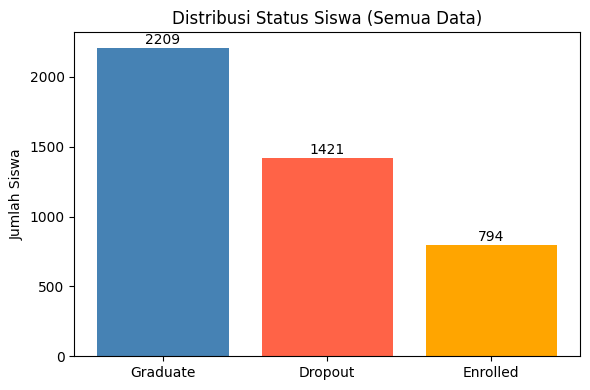

In [7]:
# distribusi status
status_count = df['Status'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(status_count.index, status_count.values, color=['steelblue', 'tomato', 'orange'])
plt.title('Distribusi Status Siswa (Semua Data)')
plt.ylabel('Jumlah Siswa')
for i, v in enumerate(status_count.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Insight:** Dari grafik terlihat Graduate adalah status terbanyak (2.209 siswa), namun Dropout juga sangat signifikan dengan **1.421 siswa (32.1%)** yang tidak menyelesaikan studi. Ini menjadi masalah serius yang perlu ditangani segera oleh pihak institusi.

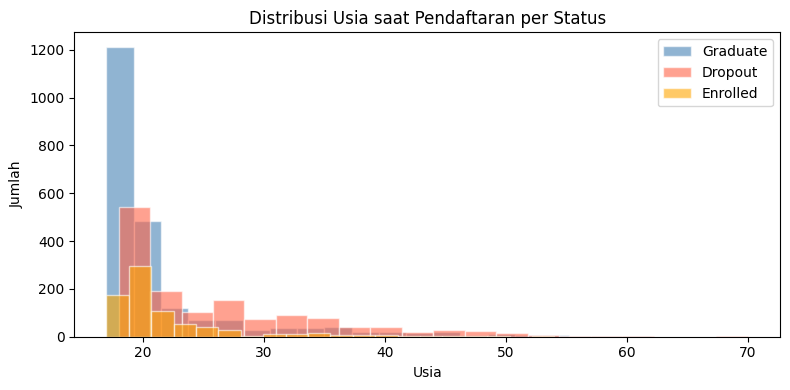

In [8]:
# distribusi usia saat mendaftar
plt.figure(figsize=(8, 4))
for status, color in zip(['Graduate', 'Dropout', 'Enrolled'], ['steelblue', 'tomato', 'orange']):
    plt.hist(df[df['Status']==status]['Age_at_enrollment'], bins=20, alpha=0.6,
             color=color, label=status, edgecolor='white')
plt.title('Distribusi Usia saat Pendaftaran per Status')
plt.xlabel('Usia')
plt.ylabel('Jumlah')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Siswa yang dropout rata-rata berusia **26.1 tahun** saat mendaftar, jauh lebih tua dibandingkan Graduate (21.8 tahun) dan Enrolled (22.4 tahun). Perbedaan usia yang cukup besar ini menunjukkan mahasiswa yang mendaftar di usia lebih tua cenderung memiliki risiko dropout lebih tinggi.

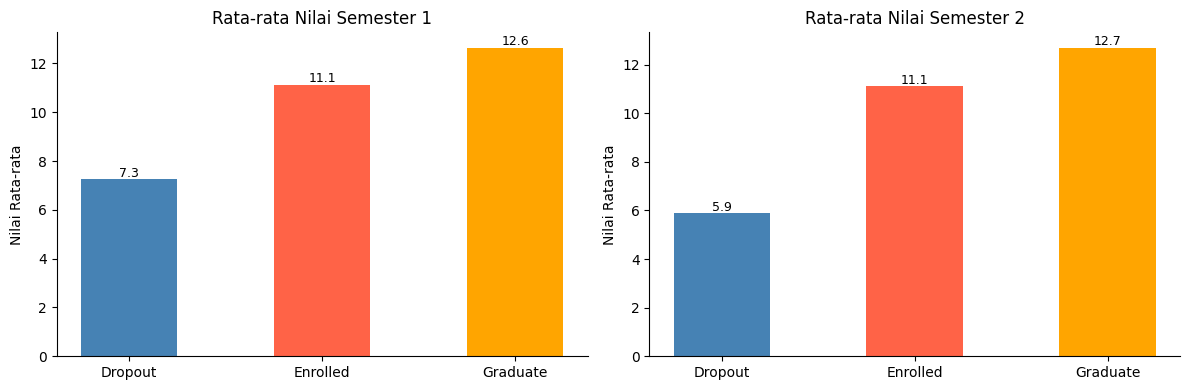

In [9]:
# perbandingan nilai semester 1 dan 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

grade1 = df.groupby('Status')['Curricular_units_1st_sem_grade'].mean()
grade2 = df.groupby('Status')['Curricular_units_2nd_sem_grade'].mean()

for ax, data, title in zip(axes, [grade1, grade2],
                            ['Rata-rata Nilai Semester 1', 'Rata-rata Nilai Semester 2']):
    colors = ['steelblue', 'tomato', 'orange']
    ax.bar(data.index, data.values, color=colors, width=0.5)
    ax.set_title(title)
    ax.set_ylabel('Nilai Rata-rata')
    for i, v in enumerate(data.values):
        ax.text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Perbedaan nilai antara kelompok status sangat signifikan. Siswa Dropout memiliki nilai rata-rata semester 1 hanya **7.26** dan semester 2 **5.90**, jauh di bawah Graduate (sem1: 12.64, sem2: 12.70).

In [10]:
debtor_rate = round(df.groupby('Status')['Debtor'].mean() * 100, 1)
debtor_rate

,Debtor
Status,
Dropout,22.0
Enrolled,11.3
Graduate,4.6


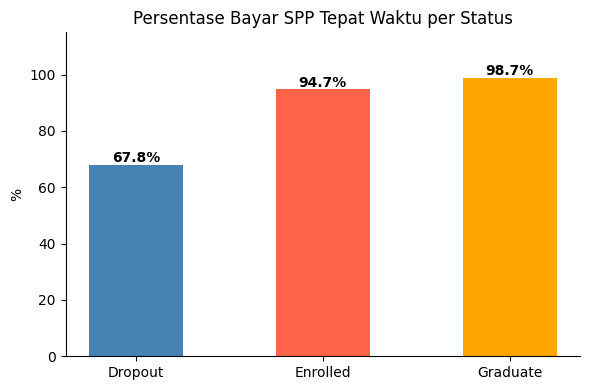

In [11]:
# pembayaran SPP vs status
tuition_rate = df.groupby('Status')['Tuition_fees_up_to_date'].mean() * 100

plt.figure(figsize=(6, 4))
plt.bar(tuition_rate.index, tuition_rate.values, color=['steelblue', 'tomato', 'orange'], width=0.5)
plt.title('Persentase Bayar SPP Tepat Waktu per Status')
plt.ylabel('%')
for i, v in enumerate(tuition_rate.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, 115)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:** Siswa yang dropout memiliki tingkat pembayaran SPP tepat waktu hanya **67.8%**, jauh di bawah Graduate (**98.7%**). Masalah finansial adalah salah satu faktor risiko dropout yang signifikan.

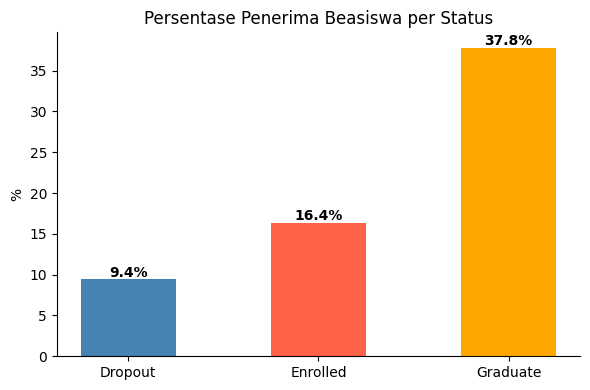

In [12]:
# pemegang beasiswa
sch_rate = df.groupby('Status')['Scholarship_holder'].mean() * 100

plt.figure(figsize=(6, 4))
plt.bar(sch_rate.index, sch_rate.values, color=['steelblue', 'tomato', 'orange'], width=0.5)
plt.title('Persentase Penerima Beasiswa per Status')
plt.ylabel('%')
for i, v in enumerate(sch_rate.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:** Proporsi penerima beasiswa sangat berbeda: **Graduate 37.8%** vs Dropout hanya **9.4%**. Beasiswa terbukti jadi faktor protektif yang kuat.

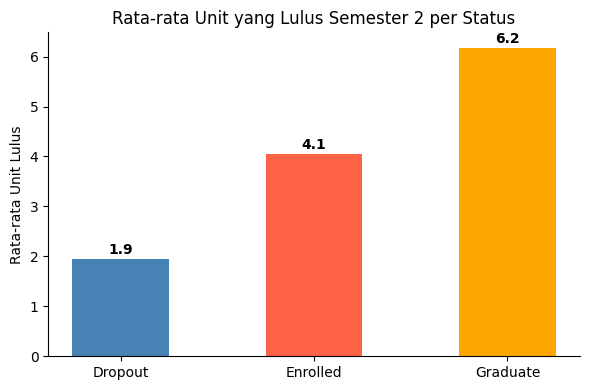

In [13]:
# units approved vs status
approved2 = df.groupby('Status')['Curricular_units_2nd_sem_approved'].mean()

plt.figure(figsize=(6, 4))
plt.bar(approved2.index, approved2.values, color=['steelblue', 'tomato', 'orange'], width=0.5)
plt.title('Rata-rata Unit yang Lulus Semester 2 per Status')
plt.ylabel('Rata-rata Unit Lulus')
for i, v in enumerate(approved2.values):
    plt.text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:** Rata-rata unit yang lulus di semester 2 sangat membedakan ketiga kelompok: Dropout hanya **1.9 unit** vs Graduate **6.2 unit**.

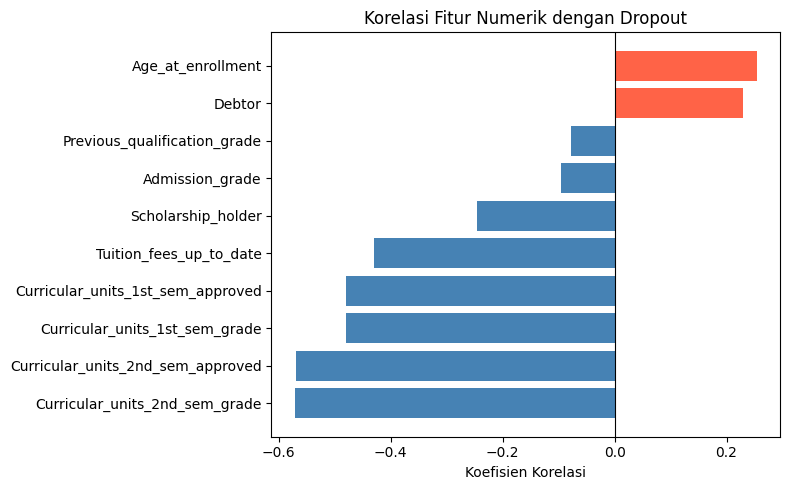

In [14]:
# korelasi fitur numerik dengan dropout (menggunakan semua data untuk EDA)
df['is_dropout'] = (df['Status'] == 'Dropout').astype(int)

num_cols = ['Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
            'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
            'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
            'Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor', 'is_dropout']

corr = df[num_cols].corr()['is_dropout'].drop('is_dropout').sort_values()

plt.figure(figsize=(8, 5))
colors_corr = ['tomato' if v > 0 else 'steelblue' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors_corr)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur Numerik dengan Dropout')
plt.xlabel('Koefisien Korelasi')
plt.tight_layout()
plt.show()

**Insight:** Korelasi negatif terkuat (mencegah dropout): nilai sem2 (-0.57), unit lulus sem2 (-0.57). Korelasi positif (meningkatkan risiko): usia saat daftar (+0.25) dan status debtor (+0.23).

## Data Preparation / Preprocessing

Sesuai tujuan pemodelan — **memprediksi apakah siswa akan Dropout atau Graduate** — kita hanya menggunakan data siswa dengan status Dropout dan Graduate. Siswa dengan status Enrolled tidak disertakan karena mereka masih aktif berkuliah dan belum memiliki outcome yang jelas.

In [15]:
# filter hanya Dropout dan Graduate
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

print('Sebelum filter (semua status):', df.shape[0], 'baris')
print('Setelah filter (hanya Dropout & Graduate):', df_model.shape[0], 'baris')
print()
print('Distribusi Status setelah filter:')
print(df_model['Status'].value_counts())

Sebelum filter (semua status): 4424 baris
Setelah filter (hanya Dropout & Graduate): 3630 baris

Distribusi Status setelah filter:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


In [16]:
# buat target binary: 1 = Dropout, 0 = Graduate
# Enrolled sudah dikeluarkan, jadi tidak ada ambiguitas encoding
df_model['Target'] = (df_model['Status'] == 'Dropout').astype(int)

print('Distribusi Target:')
print(df_model['Target'].value_counts())
print('Dropout rate:', df_model['Target'].mean()*100, '%')

Distribusi Target:
Target
0    2209
1    1421
Name: count, dtype: int64
Dropout rate: 39.146005509641874 %


In [17]:
# pisah fitur dan target — gunakan semua 36 fitur numerik
feature_cols = [c for c in df_model.columns if c not in ['Status', 'Target', 'is_dropout']]
X = df_model[feature_cols]
y = df_model['Target']

print('Jumlah fitur:', len(feature_cols))
print('Shape X:', X.shape)
print('Fitur yang digunakan:', feature_cols)

Jumlah fitur: 36
Shape X: (3630, 36)
Fitur yang digunakan: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', '

In [18]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (2904, 36)
Test size: (726, 36)


## Modeling

In [19]:
# coba logistic regression dulu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('Logistic Regression:')
print('Accuracy:', round(accuracy_score(y_test, y_pred_lr), 4))
print(classification_report(y_test, y_pred_lr, target_names=['Non-Dropout', 'Dropout']))

Logistic Regression:
Accuracy: 0.9256
              precision    recall  f1-score   support

 Non-Dropout       0.96      0.92      0.94       442
     Dropout       0.88      0.94      0.91       284

    accuracy                           0.93       726
   macro avg       0.92      0.93      0.92       726
weighted avg       0.93      0.93      0.93       726



In [20]:
# random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest:')
print('Accuracy:', round(accuracy_score(y_test, y_pred_rf), 4))
print(classification_report(y_test, y_pred_rf, target_names=['Non-Dropout', 'Dropout']))

Random Forest:
Accuracy: 0.9284
              precision    recall  f1-score   support

 Non-Dropout       0.92      0.96      0.94       442
     Dropout       0.94      0.88      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



**Insight:** Dengan dataset yang sudah difilter (hanya Dropout & Graduate), model Random Forest memberikan performa yang lebih baik dan valid. Target encoding tidak lagi ambigu karena hanya ada dua kelas yang jelas: Dropout (1) dan Graduate (0).

## Evaluation

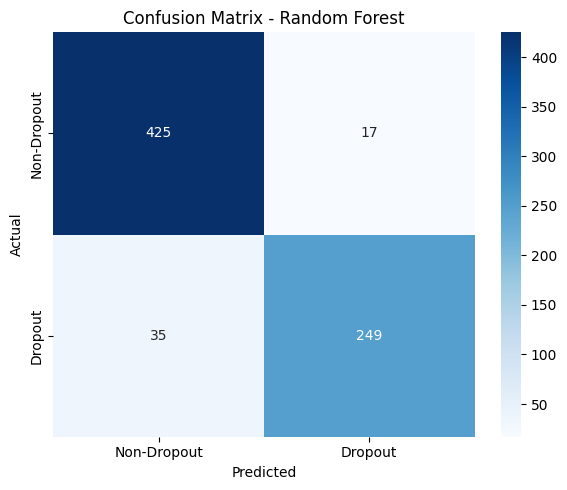

In [21]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Dropout', 'Dropout'],
            yticklabels=['Non-Dropout', 'Dropout'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

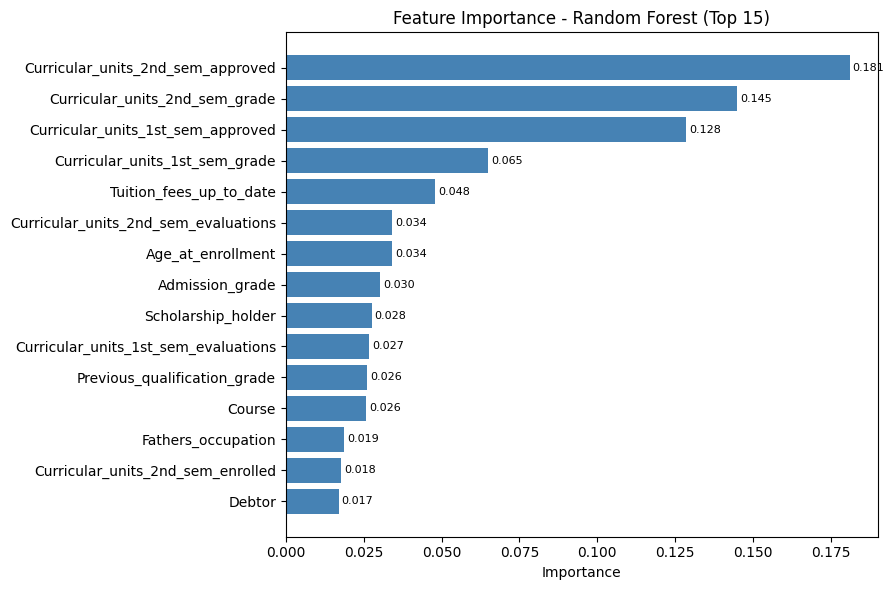

In [22]:
# feature importance
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)

plt.figure(figsize=(9, 6))
plt.barh(fi.index, fi.values, color='steelblue')
plt.title('Feature Importance - Random Forest (Top 15)')
plt.xlabel('Importance')
for i, v in enumerate(fi.values):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
# final metrics summary
y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print('=== Final Model Evaluation ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC  : {auc:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Non-Dropout', 'Dropout']))

=== Final Model Evaluation ===
Accuracy : 0.9284
AUC-ROC  : 0.9711

              precision    recall  f1-score   support

 Non-Dropout       0.92      0.96      0.94       442
     Dropout       0.94      0.88      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



In [24]:
# save model
os.makedirs("model", exist_ok=True)
joblib.dump(rf, 'model/model.pkl')
joblib.dump(feature_cols, 'model/feature_names.pkl')
print('Model berhasil disimpan ke model/model.pkl')
print('Fitur yang disimpan:', len(feature_cols))

Model berhasil disimpan ke model/model.pkl
Fitur yang disimpan: 36


In [25]:
# export data readable untuk dashboard (dengan label bukan integer)
marital_map = {1:'Single', 2:'Married', 3:'Widower', 4:'Divorced', 5:'Facto Union', 6:'Legally Separated'}
gender_map = {1:'Male', 0:'Female'}
attendance_map = {1:'Daytime', 0:'Evening'}
binary_map = {1:'Yes', 0:'No'}
course_map = {
    33:'Biofuel Production Technologies', 171:'Animation & Multimedia Design',
    8014:'Social Service (Evening)', 9003:'Agronomy', 9070:'Communication Design',
    9085:'Veterinary Nursing', 9119:'Informatics Engineering', 9130:'Equinculture',
    9147:'Management', 9238:'Social Service', 9254:'Tourism', 9500:'Nursing',
    9556:'Oral Hygiene', 9670:'Advertising & Marketing Management',
    9773:'Journalism & Communication', 9853:'Basic Education',
    9991:'Management (Evening)'
}

# Gunakan df asli (semua data) untuk dashboard — tidak hanya Dropout & Graduate
df_dash = df[feature_cols + ['Status']].copy()
df_dash['Marital_status'] = df['Marital_status'].map(marital_map).fillna('Other')
df_dash['Gender'] = df['Gender'].map(gender_map)
df_dash['Daytime_evening_attendance'] = df['Daytime_evening_attendance'].map(attendance_map)
df_dash['Displaced'] = df['Displaced'].map(binary_map)
df_dash['Debtor'] = df['Debtor'].map(binary_map)
df_dash['Tuition_fees_up_to_date'] = df['Tuition_fees_up_to_date'].map(binary_map)
df_dash['Scholarship_holder'] = df['Scholarship_holder'].map(binary_map)
df_dash['International'] = df['International'].map(binary_map)
df_dash['Course'] = df['Course'].map(course_map).fillna('Other')

df_dash.to_csv('data_dashboard.csv', index=False)
print('Dashboard CSV berhasil disimpan:', df_dash.shape)
print('Sample:')
df_dash[['Marital_status', 'Gender', 'Course', 'Status']].head(3)

Dashboard CSV berhasil disimpan: (4424, 37)
Sample:


,Marital_status,Gender,Course,Status
0,Single,Male,Animation & Multimedia Design,Dropout
1,Single,Male,Tourism,Graduate
2,Single,Male,Communication Design,Dropout
